# Aadhaar Exploratory Data Analysis (EDA)

## Objective
This notebook performs exploratory data analysis on Aadhaar enrolment, demographic update, and biometric update datasets modeled using a star schema.

Using the PIN code dimension as the central link, we derive:
- State-wise and district-wise enrolment and update trends
- Age-group-based update patterns
- PIN-level demand hotspots
- Indicators of population mobility and Aadhaar service pressure

All insights are derived without premature aggregation and respect the natural granularity of the data.


In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
sns.set_style("whitegrid")

In [163]:
dim_pincode = pd.read_csv("../data/cleaned/dim_pincode.csv")

fact_enrol = pd.read_csv("../data/cleaned/fact_enrolment.csv")
fact_demo  = pd.read_csv("../data/cleaned/fact_demographic.csv")
fact_bio   = pd.read_csv("../data/cleaned/fact_biometric.csv")

fact_enrol.shape, fact_demo.shape, fact_bio.shape

C:\Users\saima\AppData\Local\Temp\ipykernel_11996\2254708332.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  fact_demo  = pd.read_csv("../data/cleaned/fact_demographic.csv")


((1006007, 7), (527226, 6), (1861108, 6))

### PART 1: ENROLMENT EXPLORATION

In [164]:
# AGE-WISE ENROLMENT (univariate-age)
age_enrol = pd.DataFrame({
    "Age Group": ["0–5", "5–17", "18+"],
    "Enrolments": [
        fact_enrol["age_0_5"].sum(),
        fact_enrol["age_5_17"].sum(),
        fact_enrol["age_18_greater"].sum()
    ]
})

age_enrol


,Age Group,Enrolments
0,0–5,3546965
1,5–17,1720383
2,18+,168136


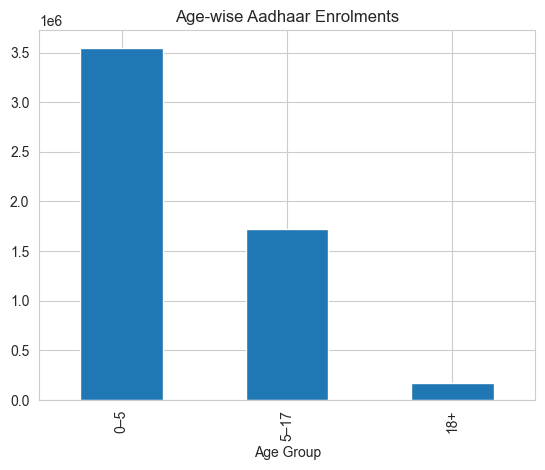

In [165]:
# Visualizing Age-wise Aadhaar Enrolments
age_enrol.plot(x="Age Group", y="Enrolments", kind="bar", legend=False)
plt.title("Age-wise Aadhaar Enrolments")
plt.show()

In [166]:
# STATE-WISE ENROLMENT (bivariate- state X enrollment)
fact_enrol["total_enrolments"] = (
    fact_enrol["age_0_5"] +
    fact_enrol["age_5_17"] +
    fact_enrol["age_18_greater"]
)

state_enrol = (
    fact_enrol.groupby("state", as_index=False)
    .agg({
        "age_0_5": "sum",
        "age_5_17": "sum",
        "age_18_greater": "sum",
        "total_enrolments": "sum"
    })
)

state_enrol


,state,age_0_5,age_5_17,age_18_greater,total_enrolments
0,andaman and nicobar islands,479,32,0,511
1,andhra pradesh,112445,13746,1495,127686
2,arunachal pradesh,1957,2236,151,4344
3,assam,141235,66085,22877,230197
4,bihar,262875,334802,11908,609585
5,chandigarh,2476,211,36,2723
6,chhattisgarh,82453,18769,1997,103219
7,dadra and nagar haveli and daman and diu,1497,250,52,1799
8,delhi,69183,22296,3050,94529
9,goa,1916,254,163,2333


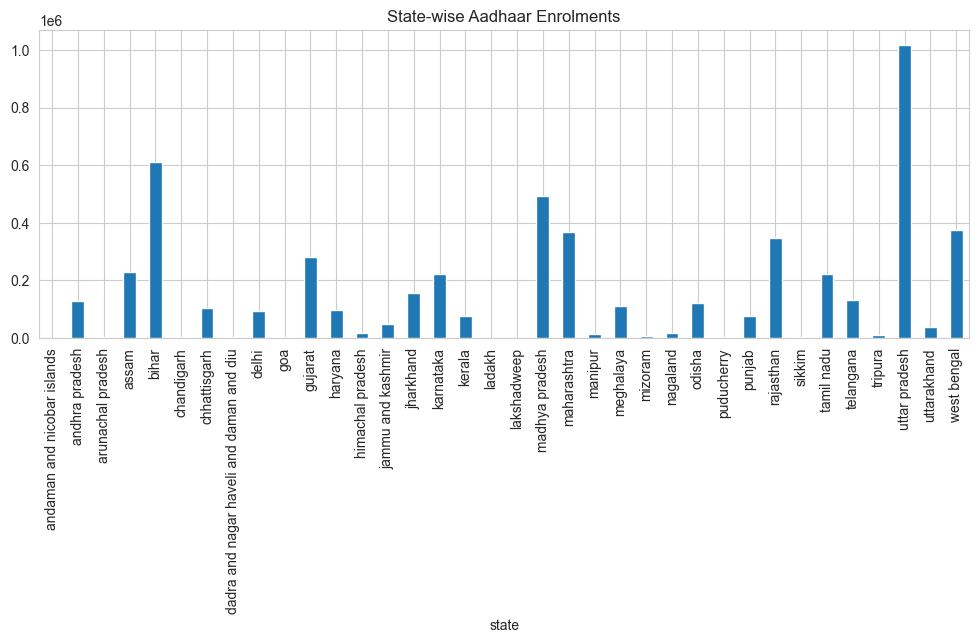

In [167]:
# Visualizing State-wise Aadhaar Enrolments
state_enrol.plot(x="state", y="total_enrolments", kind="bar", figsize=(12,4), legend=False)
plt.title("State-wise Aadhaar Enrolments")
plt.show()

In [168]:
#DISTRICT-WISE ENROLMENT (bivariate- district X enrollment)
district_enrol = (
    fact_enrol.groupby(["state", "district"], as_index=False)
    .agg({
        "age_0_5": "sum",
        "age_5_17": "sum",
        "age_18_greater": "sum",
        "total_enrolments": "sum"
    })
    # .sort_values("total_enrolments", ascending=False)
    .head(30)
)

district_enrol


,state,district,age_0_5,age_5_17,age_18_greater,total_enrolments
0,andaman and nicobar islands,Andamans,70,5,0,75
1,andaman and nicobar islands,Nicobar,64,11,0,75
2,andaman and nicobar islands,Nicobars,1,0,0,1
3,andaman and nicobar islands,North And Middle Andaman,128,4,0,132
4,andaman and nicobar islands,South Andaman,216,12,0,228
5,andhra pradesh,Adilabad,1137,281,1,1419
6,andhra pradesh,Alluri Sitharama Raju,1105,116,34,1255
7,andhra pradesh,Anakapalli,523,12,8,543
8,andhra pradesh,Anantapur,4089,326,0,4415
9,andhra pradesh,Ananthapur,1843,151,0,1994


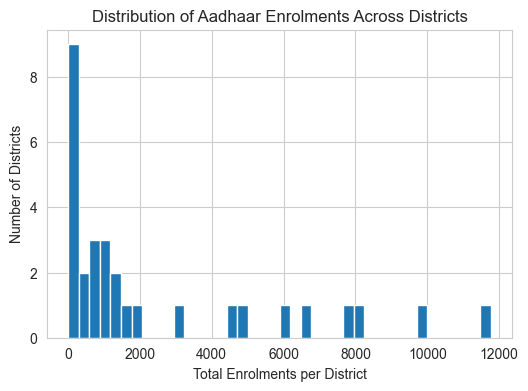

In [169]:
# Visualizing Distribution of Aadhaar Enrolments Across Districts
district_enrol["total_enrolments"].plot(
    kind="hist",
    bins=40,
    figsize=(6,4)
)

plt.title("Distribution of Aadhaar Enrolments Across Districts")
plt.xlabel("Total Enrolments per District")
plt.ylabel("Number of Districts")
plt.show()

### PART B — DEMOGRAPHIC UPDATES

In [170]:
#AGE-WISE DEMOGRAPHIC UPDATES (univariate-age)
age_demo = pd.DataFrame({
    "Age Group": ["5–17", "17+"],
    "Demographic Updates": [
        fact_demo["demo_age_5_17"].sum(),
        fact_demo["demo_age_17_"].sum()
    ]
})

age_demo


,Age Group,Demographic Updates
0,5–17,1488133.0
1,17+,13289860.0


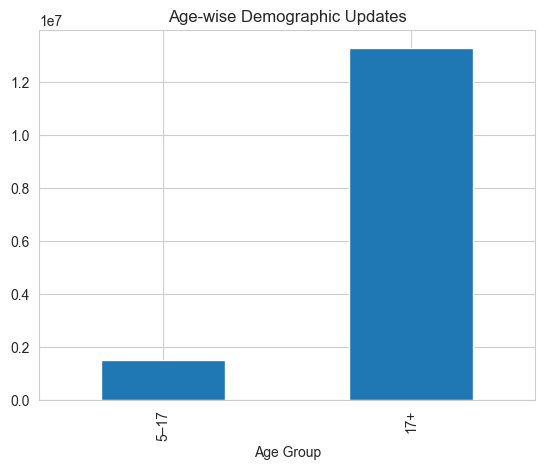

In [171]:
# Visualizing Age-wise Demographic Updates
age_demo.plot(x="Age Group", y="Demographic Updates", kind="bar", legend=False)
plt.title("Age-wise Demographic Updates")
plt.show()

In [172]:
#STATE-WISE DEMOGRAPHIC UPDATES (bivariate- state X demographic updates)
fact_demo["total_demo_updates"] = (
    fact_demo["demo_age_5_17"] +
    fact_demo["demo_age_17_"]
)

state_demo = (
    fact_demo.groupby("state", as_index=False)
    .agg({
        "demo_age_5_17": "sum",
        "demo_age_17_": "sum",
        "total_demo_updates": "sum"
    })
)

state_demo


,state,demo_age_5_17,demo_age_17_,total_demo_updates
0,andaman and nicobar islands,140.0,1590.0,1730.0
1,andhra pradesh,93255.0,584941.0,678196.0
2,arunachal pradesh,1703.0,8629.0,10332.0
3,assam,24654.0,263561.0,288215.0
4,bihar,110814.0,1319519.0,1430333.0
5,chandigarh,4902.0,24214.0,29116.0
6,chhattisgarh,49560.0,559227.0,608787.0
7,dadra and nagar haveli and daman and diu,494.0,2202.0,2696.0
8,delhi,72338.0,478627.0,550965.0
9,goa,873.0,8332.0,9205.0


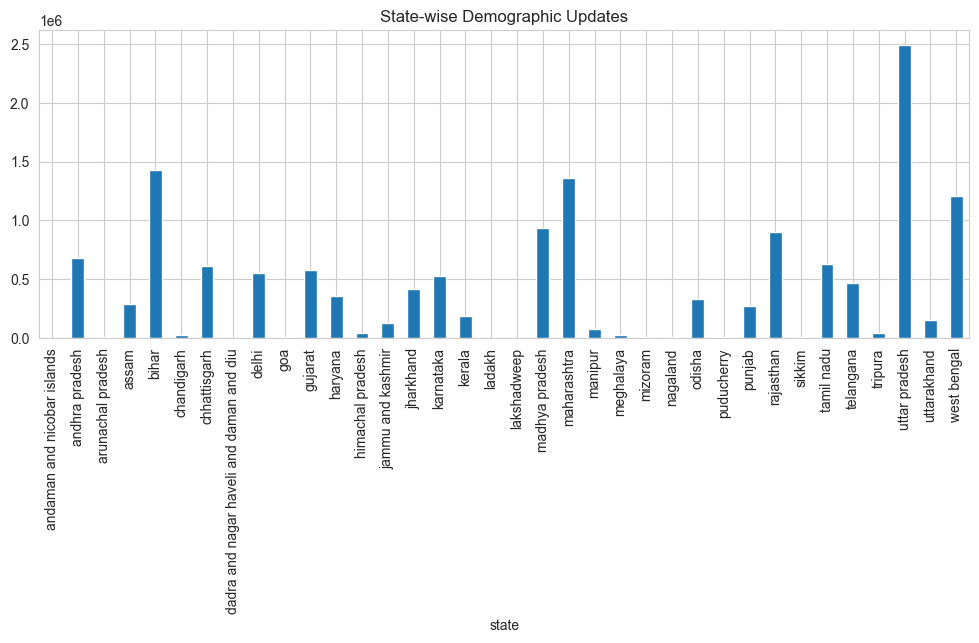

In [173]:
# Visualizing State-wise Demographic Updates
state_demo.plot(x="state", y="total_demo_updates", kind="bar", figsize=(12,4), legend=False)
plt.title("State-wise Demographic Updates")
plt.show()

In [174]:
#DISTRICT-WISE DEMOGRAPHIC UPDATES (bivariate- district X demographic updates)
district_demo = (
    fact_demo.groupby(["state", "district"], as_index=False)
    .agg({
        "demo_age_5_17": "sum",
        "demo_age_17_": "sum",
        "total_demo_updates": "sum"
    })
    # .sort_values("total_enrolments", ascending=False)
    .head(30)
)

district_demo


,state,district,demo_age_5_17,demo_age_17_,total_demo_updates
0,andaman and nicobar islands,Andamans,2.0,189.0,191.0
1,andaman and nicobar islands,Nicobar,4.0,60.0,64.0
2,andaman and nicobar islands,Nicobars,0.0,3.0,3.0
3,andaman and nicobar islands,North And Middle Andaman,44.0,639.0,683.0
4,andaman and nicobar islands,South Andaman,90.0,699.0,789.0
5,andhra pradesh,Adilabad,740.0,7010.0,7750.0
6,andhra pradesh,Alluri Sitharama Raju,532.0,3749.0,4281.0
7,andhra pradesh,Anakapalli,473.0,3044.0,3517.0
8,andhra pradesh,Anantapur,2418.0,15918.0,18336.0
9,andhra pradesh,Ananthapur,2804.0,6183.0,8987.0


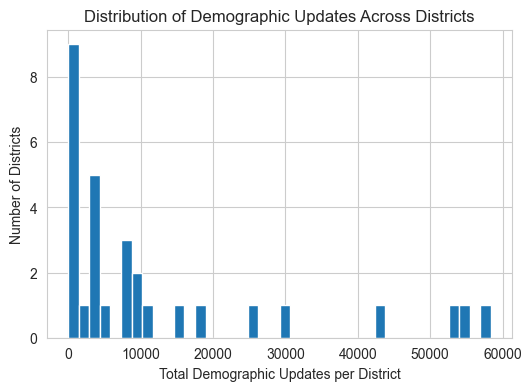

In [175]:
# Visualizing Distribution of Demographic Updates Across Districts
district_demo["total_demo_updates"].plot(
    kind="hist",
    bins=40,
    figsize=(6,4)
)

plt.title("Distribution of Demographic Updates Across Districts")
plt.xlabel("Total Demographic Updates per District")
plt.ylabel("Number of Districts")
plt.show()


### PART C — BIOMETRIC UPDATES

In [176]:
#AGE-WISE BIOMETRIC UPDATES (univariate-age)
age_bio = pd.DataFrame({
    "Age Group": ["5–17", "18+"],
    "Biometric Updates": [
        fact_bio["bio_age_5_17"].sum(),
        fact_bio["bio_age_17_"].sum()
    ]
})

age_bio

,Age Group,Biometric Updates
0,5–17,34226855
1,18+,35536240


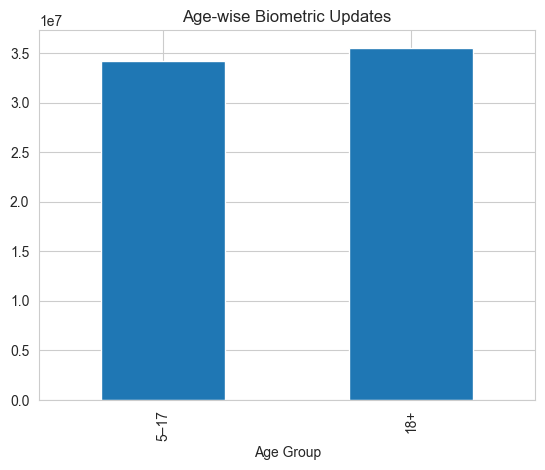

In [177]:
# Visualizing Age-wise Biometric Updates
age_bio.plot(x="Age Group", y="Biometric Updates", kind="bar", legend=False)
plt.title("Age-wise Biometric Updates")
plt.show()

In [178]:
# STATE-WISE BIOMETRIC UPDATES (bivariate- state X biometric updates)
fact_bio["total_bio_updates"] = (
    fact_bio["bio_age_5_17"] +
    fact_bio["bio_age_17_"]
)

state_bio = (
    fact_bio.groupby("state", as_index=False)
    .agg({
        "bio_age_5_17": "sum",
        "bio_age_17_": "sum",
        "total_bio_updates": "sum"
    })
)

state_bio

,state,bio_age_5_17,bio_age_17_,total_bio_updates
0,andaman and nicobar islands,11806,8892,20698
1,andhra pradesh,2241467,1473166,3714633
2,arunachal pradesh,42894,29500,72394
3,assam,596624,386098,982722
4,bihar,2208141,2689446,4897587
5,chandigarh,49171,25311,74482
6,chhattisgarh,884555,1764179,2648734
7,dadra and nagar haveli and daman and diu,16362,22906,39268
8,delhi,556237,748125,1304362
9,goa,34244,34153,68397


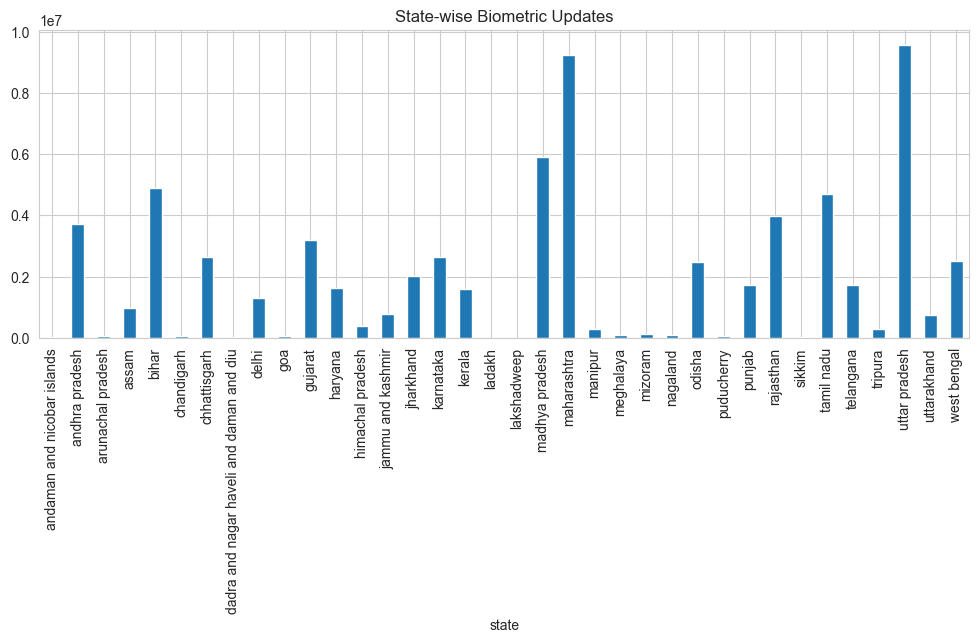

In [179]:
# Visualizing State-wise Biometric Updates
state_bio.plot(x="state", y="total_bio_updates", kind="bar", figsize=(12,4), legend=False)
plt.title("State-wise Biometric Updates")
plt.show()

In [180]:
#DISTRICT-WISE BIOMETRIC UPDATES (bivariate- district X biometric updates)
district_bio = (
    fact_bio.groupby(["state", "district"], as_index=False)
    .agg({
        "bio_age_5_17": "sum",
        "bio_age_17_": "sum",
        "total_bio_updates": "sum"
    })
    # .sort_values("total_enrolments", ascending=False)
    .head(30)
)

district_bio


,state,district,bio_age_5_17,bio_age_17_,total_bio_updates
0,andaman and nicobar islands,Andamans,343,1672,2015
1,andaman and nicobar islands,Nicobar,992,819,1811
2,andaman and nicobar islands,Nicobars,1,1,2
3,andaman and nicobar islands,North And Middle Andaman,3780,2603,6383
4,andaman and nicobar islands,South Andaman,6690,3797,10487
5,andhra pradesh,Adilabad,12208,39830,52038
6,andhra pradesh,Alluri Sitharama Raju,8438,10169,18607
7,andhra pradesh,Anakapalli,3542,3181,6723
8,andhra pradesh,Anantapur,35834,57731,93565
9,andhra pradesh,Ananthapur,64082,20050,84132


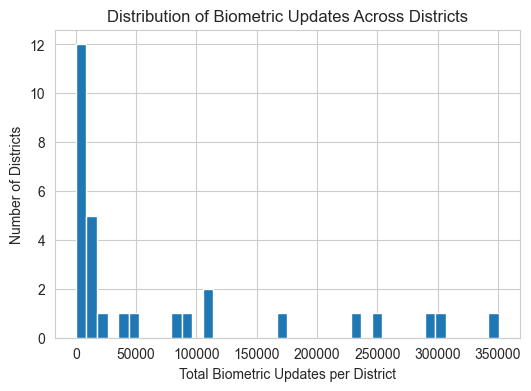

In [181]:
# Visualizing Distribution of Biometric Updates Across Districts
district_bio["total_bio_updates"].plot(
    kind="hist",
    bins=40,
    figsize=(6,4)
)

plt.title("Distribution of Biometric Updates Across Districts")
plt.xlabel("Total Biometric Updates per District")
plt.ylabel("Number of Districts")
plt.show()
